# Minimum Randomness under Latency constraints (MRLC)

This notebook demonstrates the MRLC algorithm for analyzing and optimizing masked cryptographic circuits with register balancing.

## Overview
- **MRLC**: Computes minimum latency required for multi-share circuits
- **AND Tree**: Builds AND gate dependency graph
- **Gadget Optimization**: Applies HPC2 gadget transformations
- **Performance Analysis**: Measures latency and AND depth metrics

# **TETRIS Flow**
### 1. **TAC Generation** <br>
**Input**: C code 
- We start with C code file which we transform into TAC format. 
- Here TAC means RHS of every assigment contains only one operand, e.g., a = b + c is allowed but a = b+c+d is not allowed
- *convert_to_TAC* function converts the C file into TAC format.

In [1]:
# and cloud of input file 
import dse_pipeline
import importlib
from dse_pipeline import convert_to_TAC, run_inliner, generator_and_cloud, run_maskedHLS, generator_and_xor_cloud
from PIL import Image # type: ignore
from IPython.display import display # type: ignore

# 1. convert the test c file to tac
try:
    print("[INFO] Converting Canright_sbox.c to TAC format...")
    convert_to_TAC('/home/tapish08/Desktop/DSE-Framework/TestFiles/C_files/Canright_sbox.c')
    print("[SUCCESS] TAC conversion completed successfully!")
except Exception as e:
    print(f"[ERROR] TAC conversion failed: {e}")
    import traceback
    traceback.print_exc()


[INFO] Converting Canright_sbox.c to TAC format...
[INFO] : Transforming input file to TAC ...
[INFO] : TAC output written to /home/tapish08/Desktop/DSE-Framework/TestFiles/TAC_files/output.c

[SUCCESS] TAC conversion completed successfully!


### 2. **AND Tree Generation**
- For and Tree Generation we first inline the TAC C format file.
- The inline C code preserves the dependency between the and operation present in the C code.
- This inlined file is then used to generate the **AND** tree. 

[INFO] : Inlining the TAC file ...
[INFO] : systemArgs.json written:
{
    "inputFile": "/home/tapish08/Desktop/DSE-Framework/TestFiles/TAC_files/output.c",
    "inlinerOutput": "/home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c",
    "topModule": "sbox",
    "turn": 1
}

[INFO] : Subprocess CWD will be: /home/tapish08/Desktop/DSE-Framework/MaskedHLS_LP/src

[INFO] : Inlined file written to /home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c

[INFO] Generating AND tree (pure AND gates for MRLC DP)...
[INFO] : Generating the AND tree ...
[INFO] : Number of node in the tree :36
[INFO] : Saving graph
[INFO] AND tree generated with 36 nodes

[INFO] Generating AND-XOR tree (for pattern detection)...
[INFO] : Generating the AND_Xor tree ...
[INFO] : Number of node in the tree :168
[INFO]:Saving AND_Xor tree graph to: ./ANDCloud/AND_Xor_tree/and_xor_cloud.png
[INFO] : Saving graph
[INFO] XOR graph successfully saved to: ./ANDCloud/AND_Xor_tree/and_xor_g

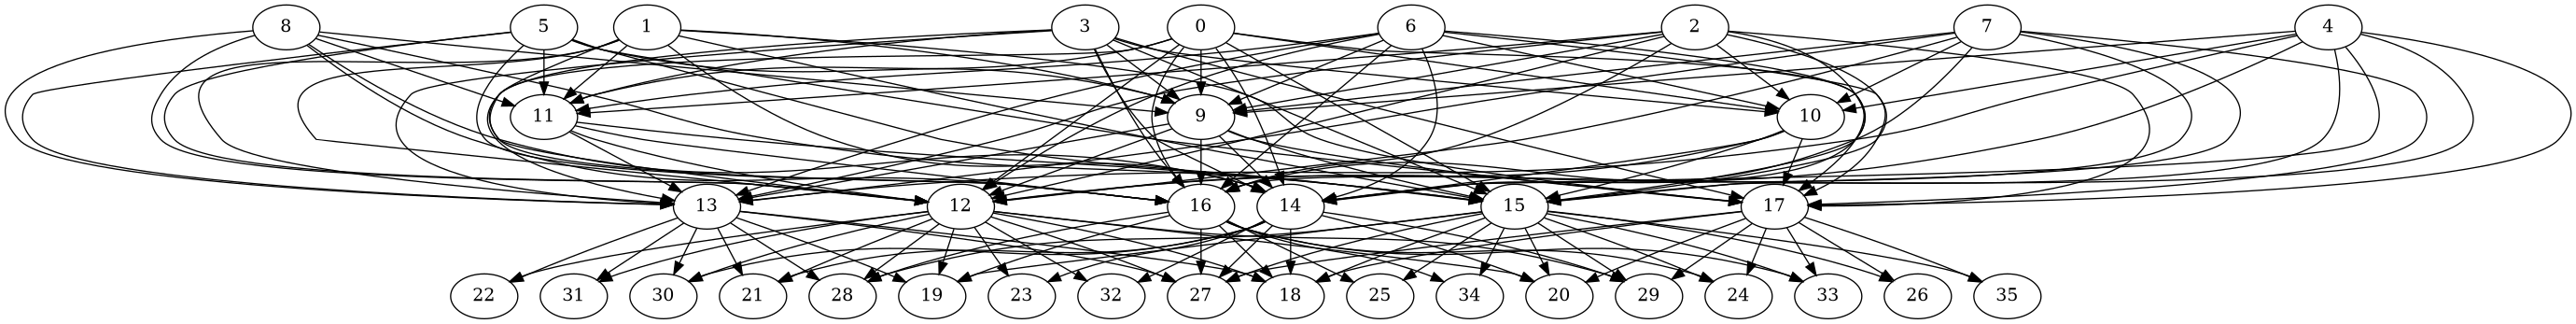

In [2]:
# 2. run inliner
run_inliner('/home/tapish08/Desktop/DSE-Framework/TestFiles/TAC_files/output.c','sbox')

# 3. get BOTH trees - AND tree and AND-XOR tree
print("[INFO] Generating AND tree (pure AND gates for MRLC DP)...")
and_tree = generator_and_cloud('/home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c')
print(f"[INFO] AND tree generated with {len(list(and_tree.graph.nodes()))} nodes")

print("\n[INFO] Generating AND-XOR tree (for pattern detection)...")
and_xor_tree = generator_and_xor_cloud('/home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c')
print(f"[INFO] AND-XOR tree generated")
print(f"[DEBUG] and_xor_tree type: {type(and_xor_tree)}")
print(f"[DEBUG] and_xor_tree attributes: {[a for a in dir(and_xor_tree) if not a.startswith('_')]}")

if hasattr(and_xor_tree, 'nodes_by_level'):
    print(f"[DEBUG] and_xor_tree.nodes_by_level exists with {len(and_xor_tree.nodes_by_level)} levels")
else:
    print("[DEBUG] and_xor_tree does NOT have nodes_by_level")

print("\n[INFO] Tree Strategy:")
print("  - and_tree: Used for MRLC DP algorithm (pure AND gates)")
print("  - and_xor_tree: Used for AND-XOR pattern detection")

# 4. get the image
image = Image.open('/home/tapish08/Desktop/DSE-Framework/ANDCloud/AND_tree/and_cloud.png')  # Change to your image path
display(image)

### 3. **Get the Gadgets available for masking order d**


In [7]:
import sqlite3
# create db if does not exist

d = 1
print(f"[INFO] : Connecting Database ... ")
conn = sqlite3.connect('gadget_info.db')
conn.execute("PRAGMA forgien_keys = ON")
cur = conn.cursor()

[INFO] : Connecting Database ... 


In [8]:

from tabulate import tabulate # type: ignore


gadget_specs = {}
gadget_list = ["hpc3", "hpc2", "hpc2_swapped"] if d == 1 else ["hpc1", "hpc2", "hpc3", "hpc2o", "hpc3o"]
# gadget_list = ["hpc1", "hpc2", "hpc3", "hpc2o", "hpc3o", "hpc2_swapped", "hpc2o_swapped"] if d == 1 else ["hpc1", "hpc2", "hpc3", "hpc2o", "hpc3o", "hpc2_swapped", "hpc2o_swapped"]

# gadget_list = ["hpc2"] if d == 1 else ["hpc2"]
for gadget in gadget_list:
    table = gadget.lower()
    # print(f"[INFO] : d value while populating the map : {d}")
    cur.execute(f"SELECT * FROM {table} WHERE d = ?", (d,))
    row = cur.fetchone()

    if row:
        gadget_specs[gadget] = {
            "latency": row[1],
            "randomness": row[2],
            "area": row[3]
        }
    else:
        print(f"[WARN] No entry for {gadget} with d = {d}")
if gadget_specs:
    table_data =[]
    for gadget, values in gadget_specs.items():
        table_data.append([gadget, values['latency'], values['randomness'], values['area']])
    print(f"\n[INFO]: Populated DSE MAP for {d} order")

    # from tabulate import tabulate
    print(tabulate(table_data, headers=["Gadget", "Latency", "randomness","area"], tablefmt="grid"))

# DSE.set_gadget_specs(gadget_specs)
# print(f"DSE.GADGET_gadget_specs :\n {DSE.GADGET_gadget_specs}")
conn.commit()



[INFO]: Populated DSE MAP for 1 order
+--------------+-----------+--------------+--------+
| Gadget       |   Latency |   randomness |   area |
+==============+===========+==============+========+
| hpc3         |         1 |            2 |      4 |
+--------------+-----------+--------------+--------+
| hpc2         |         2 |            1 |      5 |
+--------------+-----------+--------------+--------+
| hpc2_swapped |         2 |            1 |      5 |
+--------------+-----------+--------------+--------+


## 4. RUN **MRLC** 

In [9]:
from Gadgets import base, HPC2, HPC1, HPC3, COMAR, Domand
import importlib
import DSE_algorithm.mlrc 
import DSE_algorithm.dse
from DSE_algorithm.mrlc import MRLC
import time

importlib.reload(DSE_algorithm.mrlc)
importlib.reload(DSE_algorithm.dse)

# Create MRLC object with latency budget of 4
# Pass both and_tree (for DP) and and_xor_tree (for pattern detection)
mrlc_obj = MRLC(d=1,and_tree=and_tree, gadget_map=gadget_specs, and_xor_tree=and_xor_tree)
mrlc_obj.debug = True  # Set to False for cleaner output (or True to see DP tables)

print("[INFO] Running MRLC with target latency = 4...")
print("[INFO] NOTE: With critical path depth, 4 cycles is sufficient for 34 AND gates!\n")
print("[INFO] Pattern detection: Using and_xor_tree")
print("[INFO] DP algorithm: Using and_tree\n")

# Start timing
start_time = time.time()
print(f"[TIMING] Starting at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}\n")

mrlc_obj._mrlc_dp(5)

# End timing
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\n[MRLC FINAL RESULTS]")
print(f"  Total randomness: {mrlc_obj.total_randomness_after_mrlc}")
print(f"  Total latency: {mrlc_obj.total_latency_after_mrlc}")
print(f"  DAG levels (critical path): {mrlc_obj.DAG_levels}")

# Print timing information
print(f"\n[TIMING RESULTS]")
print(f"  Elapsed time: {elapsed_time:.4f} seconds ({elapsed_time*1000:.2f} ms)")
print(f"  Completed at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")

[INFO] Running MRLC with target latency = 4...
[INFO] NOTE: With critical path depth, 4 cycles is sufficient for 34 AND gates!

[INFO] Pattern detection: Using and_xor_tree
[INFO] DP algorithm: Using and_tree

[TIMING] Starting at: 2026-05-11 22:21:52

[DEBUG] gadget_map keys: ['hpc3', 'hpc2', 'hpc2_swapped']
[DEBUG] hpc2o present? False
[DEBUG] hpc3o present? False
[DEBUG] and_xor_tree available? True

[MRLC INFO] Starting MRLC-DP with target_latency=5

--- Analyzing AND-XOR Tree for Patterns (Fan-out based) ---
  [MULTI-FANOUT] m4_e_G4_mul0_G16_mul0_G256_inv0 = m4_ab_G4_mul0_G16_mul0_G256_inv0 & m4_cd_G4_mul0_G16_mul0_G256_inv0
               has 2 consumers: m16_e0_s1_G16_mul0_G256_inv0 = temp_var_1_G4_mul0_G16_mul0_G256_inv0 ^ m4_e_G4_mul0_G16_mul0_G256_inv0, m16_e1_s1_G16_mul0_G256_inv0 = temp_var_0_G4_mul0_G16_mul0_G256_inv0 ^ m4_e_G4_mul0_G16_mul0_G256_inv0
               → CANNOT use HPC2o/HPC3o (needs exclusive XOR consumer)
  [W-LATE] temp_var_0_G4_mul0_G16_mul0_G256_inv0 = m

In [10]:
## 4.1 Apply Asymmetric Gadget Optimization (HPC2/HPC2o)

# Diagnostic: Check and_xor_tree structure
print("[DIAGNOSTIC] and_xor_tree Structure Check")
print("=" * 60)
if hasattr(and_xor_tree, 'level_nodes'):
    print("✓ and_xor_tree has 'level_nodes' attribute")
elif hasattr(and_xor_tree, 'nodes_by_level'):
    print("✓ and_xor_tree has 'nodes_by_level' attribute")
else:
    print("✗ Warning: and_xor_tree structure not recognized")
print()

# Import the optimization pass
from asymmetric_gadget_optimization import optimize_mrlc_with_asymmetric_gadgets

print("[INFO] Applying asymmetric gadget optimization...")
print("[INFO] This pass optimizes HPC3 nodes to HPC2 using input depth differences\n")

# Apply optimization WITH DEBUG ENABLED to see depth computation
mrlc_obj = optimize_mrlc_with_asymmetric_gadgets(mrlc_obj, and_xor_tree, debug=True)

print(f"\n[OPTIMIZATION COMPLETE]")
print(f"  Updated randomness: {mrlc_obj.total_randomness_after_mrlc}")
print(f"  Latency maintained: {mrlc_obj.total_latency_after_mrlc}")

# Verify HPC2/HPC2o gadgets are in gadget_definition
hpc2_count = sum(1 for info in mrlc_obj.gadget_definition.values() if info.get("gadget_name") in ['hpc2', 'hpc2o'])
print(f"\n[VERIFICATION] HPC2/HPC2o gadgets in gadget_definition: {hpc2_count}")


[DIAGNOSTIC] and_xor_tree Structure Check
✓ and_xor_tree has 'level_nodes' attribute

[INFO] Applying asymmetric gadget optimization...
[INFO] This pass optimizes HPC3 nodes to HPC2 using input depth differences


ASYMMETRIC GADGET OPTIMIZATION PASS (HPC3 → HPC2 / HPC2_swapped)

[DEBUG] gadget_definition type: <class 'dict'>
[DEBUG] gadget_definition size: 36

[DEBUG] Gadget distribution:
  hpc2           :  33 gates
  hpc3           :   3 gates

[DEBUG] HPC3/HPC3o gates found: 3
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [SKIP] Not HPC3/HPC3o: hpc2
  [DEPTH DEBUG] m4_e_G4_mul3_G16_inv0_G256_inv0 = m4_ab_G4_mul3_G16_inv0_G25
    op_A: m4_ab_G4_mul3_G16_inv0_G256_inv0 (depth: 1)
    op_B: m4_cd_G4_mul3_G16_inv0_G256_inv0 (depth: 1)
    diff: 0
    HPC3 latency: 2, HPC2 latency: 3
    Can opt

In [14]:
# create the ast for the inlined file 
import os
from pycparser import parse_file, c_ast, c_generator
import transform_CFile.ctransfromer
from transform_CFile.ctransfromer import ShareTransformer
importlib.reload(transform_CFile.ctransfromer)
from DSE_algorithm.mrlc import MRLC
import time

# Start overall timing
overall_start = time.time()
print(f"[TIMING] Pipeline started at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(overall_start))}\n")

inlined_file = os.path.abspath(r"./TestFiles/inlined_output/output.c")
ast = parse_file(inlined_file)

print("\n[PIPELINE] Step 1: Get gadget definitions from MRLC")
step1_start = time.time()
gadget_map = mrlc_obj.get_gadget_definition()
step1_time = time.time() - step1_start
print(f"  ⏱ Step 1 completed in {step1_time:.4f}s\n")

print("[PIPELINE] Step 2: Get unique gadget definitions from MRLC")
step2_start = time.time()
unique_definition_map = mrlc_obj.get_unique_gadgets_definition()
step2_time = time.time() - step2_start

print(f"\n[RESULT] Unique gadget definitions:")
for gadget_name in sorted(unique_definition_map.keys()):
    func_code = unique_definition_map[gadget_name]
    lines = len(func_code.split('\n'))
    print(f"  ✓ {gadget_name:8} : {lines:3} lines")
print(f"  ⏱ Step 2 completed in {step2_time:.4f}s\n")

# Verify all required gadgets are present
required_gadgets = {'hpc2', 'hpc2o', 'hpc3', 'hpc3o', 'hpc2_swapped', 'hpc2o_swapped', 'comar'}
missing = required_gadgets - set(unique_definition_map.keys())
if missing:
    print(f"\n[ERROR] Missing: {missing}")
else:
    print(f"\n[SUCCESS] All 7 gadgets present!")

print(f"\n[PIPELINE] Step 3: Create ShareTransformer")
step3_start = time.time()
shareTransformer = ShareTransformer(d+1, gadget_map, unique_definition_map)
step3_time = time.time() - step3_start
print(f"  ⏱ Step 3 completed in {step3_time:.4f}s\n")

print("[PIPELINE] Step 4: Transform circuit (suppressing verbose output...)")
step4_start = time.time()
# Suppress the verbose debug output during transformation
import sys
from io import StringIO

# Temporarily redirect stdout to suppress prints
old_stdout = sys.stdout
sys.stdout = StringIO()

try:
    transformed_ast = shareTransformer.transform(ast)
finally:
    # Restore stdout
    sys.stdout = old_stdout

step4_time = time.time() - step4_start
print(f"  ⏱ Step 4 completed in {step4_time:.4f}s\n")

print("[PIPELINE] Step 5: Generate C code")
step5_start = time.time()
gen = c_generator.CGenerator()
step5_time = time.time() - step5_start
print(f"  ⏱ Step 5 completed in {step5_time:.4f}s\n")

output_path = os.path.abspath(r"./TestFiles/share_output/output.c")
os.makedirs(os.path.dirname(output_path), exist_ok=True)

print("[PIPELINE] Step 6: Write output to file")
step6_start = time.time()
with open(output_path, 'w') as f:
    f.write("// === GADGET DEFINITIONS ===\n")
    for gadget_name, func_str in unique_definition_map.items():
        f.write(f"\n// --- {gadget_name} ---\n")
        f.write(func_str)
        f.write("\n\n")
    
    code = gen.visit(transformed_ast)
    f.write(code)

step6_time = time.time() - step6_start
print(f"  ⏱ Step 6 completed in {step6_time:.4f}s\n")

# Calculate overall timing
overall_end = time.time()
total_time = overall_end - overall_start

print(f"[SUCCESS] Output written to {output_path}")
print(f"\n{'='*80}")
print(f"[TIMING SUMMARY]")
print(f"{'='*80}")
print(f"  Step 1 (Get gadget definitions)     : {step1_time:8.4f}s")
print(f"  Step 2 (Get unique definitions)     : {step2_time:8.4f}s")
print(f"  Step 3 (Create ShareTransformer)    : {step3_time:8.4f}s")
print(f"  Step 4 (Transform circuit)          : {step4_time:8.4f}s  ⭐ (Longest)")
print(f"  Step 5 (Generate C code)            : {step5_time:8.4f}s")
print(f"  Step 6 (Write to file)              : {step6_time:8.4f}s")
print(f"  {'-'*80}")
print(f"  TOTAL PIPELINE TIME                 : {total_time:8.4f}s ({total_time*1000:.2f} ms)")
print(f"{'='*80}\n")


[TIMING] Pipeline started at: 2026-04-30 00:33:12


[PIPELINE] Step 1: Get gadget definitions from MRLC

MRLC: GET_GADGET_DEFINITION()
[INFO] Preparing gadget_definition with 36 entries

[GADGET BREAKDOWN]
  hpc2    :  24 gates
  hpc3    :  12 gates

[HPC2/HPC2o OPTIMIZED GATES] (24 gates)
  m4_e_G4_mul4_G16_inv0_G256_inv0 = m4_ab_G4_mul4_G16_inv0_G25 → hpc2
  temp_var_0_G4_mul4_G16_inv0_G256_inv0 = i16_e1_G16_inv0_G256 → hpc2
  temp_var_1_G4_mul4_G16_inv0_G256_inv0 = i16_e0_G16_inv0_G256 → hpc2
  m4_e_G4_mul5_G16_inv0_G256_inv0 = m4_ab_G4_mul5_G16_inv0_G25 → hpc2
  temp_var_0_G4_mul5_G16_inv0_G256_inv0 = i16_e1_G16_inv0_G256 → hpc2
  ... and 19 more

  ⏱ Step 1 completed in 0.0003s

[PIPELINE] Step 2: Get unique gadget definitions from MRLC
[MRLC] get_unique_gadgets_definition() called
[MRLC] Gadgets actually used in gadget_definition: {'hpc3': 12, 'hpc2': 24}
[MRLC] Currently in unique_gadgets_definition: ['hpc3', 'hpc2']

[MRLC] Generating definitions for: ['hpc2_swapped', 'hpc2o', 

## Run **MaskedHLS**

In [15]:
# run the maskedhls to get the verilog code of the masked file
import os 
# import numpy as np
# from scipy.optimize import linprog
top_module = 'sbox'
input_file = os.path.abspath("./TestFiles/share_output/output.c")
print(f"Input file for maskedHLS : {input_file}")

latency = run_maskedHLS(top_module=top_module, input_file=input_file, rtl_file='test.v', bit_width=1)



Input file for maskedHLS : /home/tapish08/Desktop/DSE-Framework/TestFiles/share_output/output.c
[INFO] : Running Command: python3 script.py --topModule=sbox --inputFile=/home/tapish08/Desktop/DSE-Framework/TestFiles/share_output/output.c --rtlFile=test.v --bitWidth=1
[INFO] Script output:
 
----------Nodes and edges------------
1062
1581
-------------------------------------
Max path weight 4
useLineAlgo from set_source_sink_weight
No of registers if added levelwise: 2274
Execution Time
--- 0.6782221794128418 seconds ---
----------Nodes and edges------------
1062
1581
-------------------------------------
Max path weight 4
useLineAlgo from set_source_sink_weight
No of registers if added levelwise: 2274
Execution Time
--- 0.5758466720581055 seconds ---

[INFO] : Latency of the design: 4


In [46]:

# Comprehensive Level Analysis: Detailed View of ALL Nodes at Each Level
print("\n" + "="*120)
print("DETAILED CIRCUIT LEVEL ANALYSIS - ALL NODES BY LEVEL")
print("="*120)

if hasattr(mrlc_obj, 'nodes_by_level'):
    nodes_by_level = mrlc_obj.nodes_by_level
    
    # Create a detailed report
    level_summary = []
    
    for level in sorted(nodes_by_level.keys()):
        nodes_at_level = nodes_by_level[level]
        node_count = len(nodes_at_level)
        
        # Categorize nodes
        and_nodes = []
        xor_nodes = []
        mixed_nodes = []
        other_nodes = []
        
        for node in nodes_at_level:
            node_str = str(node)
            if ' & ' in node_str and ' ^ ' in node_str:
                mixed_nodes.append(node_str)
            elif ' & ' in node_str:
                and_nodes.append(node_str)
            elif ' ^ ' in node_str:
                xor_nodes.append(node_str)
            else:
                other_nodes.append(node_str)
        
        level_summary.append({
            'level': level,
            'total': node_count,
            'and': len(and_nodes),
            'xor': len(xor_nodes),
            'mixed': len(mixed_nodes),
            'other': len(other_nodes)
        })
        
        # Print header for this level
        print(f"\n{'█'*120}")
        print(f"LEVEL {level}  |  Total: {node_count:3d}  |  AND: {len(and_nodes):3d}  |  XOR: {len(xor_nodes):3d}  |  MIXED: {len(mixed_nodes):3d}  |  OTHER: {len(other_nodes):3d}")
        print(f"{'█'*120}")
        
        # Display all nodes at this level
        all_level_nodes = and_nodes + xor_nodes + mixed_nodes + other_nodes
        
        for idx, node_str in enumerate(all_level_nodes, 1):
            # Determine operation type
            if ' & ' in node_str and ' ^ ' in node_str:
                op_type = "MIXED"
                symbol = "🔄"
            elif ' & ' in node_str:
                op_type = "AND"
                symbol = "▲"
            elif ' ^ ' in node_str:
                op_type = "XOR"
                symbol = "◆"
            else:
                op_type = "OTHER"
                symbol = "◎"
            
            # Format node string
            if len(node_str) > 110:
                display_str = node_str[:107] + "..."
            else:
                display_str = node_str
            
            print(f"  {symbol} [{idx:3d}] {display_str:110s}  [{op_type}]")
    
    # Print summary table
    print(f"\n{'='*120}")
    print("LEVEL SUMMARY TABLE")
    print(f"{'='*120}")
    print(f"{'LEVEL':>6} | {'TOTAL':>6} | {'AND':>6} | {'XOR':>6} | {'MIXED':>6} | {'OTHER':>6} | % AND | % XOR | % MIXED")
    print(f"{'-'*120}")
    
    for summary in level_summary:
        total = summary['total']
        and_count = summary['and']
        xor_count = summary['xor']
        mixed_count = summary['mixed']
        other_count = summary['other']
        
        and_pct = (and_count / total * 100) if total > 0 else 0
        xor_pct = (xor_count / total * 100) if total > 0 else 0
        mixed_pct = (mixed_count / total * 100) if total > 0 else 0
        
        print(f"{summary['level']:>6} | {total:>6} | {and_count:>6} | {xor_count:>6} | {mixed_count:>6} | {other_count:>6} | {and_pct:>5.1f}% | {xor_pct:>5.1f}% | {mixed_pct:>6.1f}%")
    
    # Global statistics
    print(f"\n{'='*120}")
    print("GLOBAL STATISTICS")
    print(f"{'='*120}")
    
    total_levels = len(nodes_by_level)
    total_nodes = sum(s['total'] for s in level_summary)
    total_and = sum(s['and'] for s in level_summary)
    total_xor = sum(s['xor'] for s in level_summary)
    total_mixed = sum(s['mixed'] for s in level_summary)
    total_other = sum(s['other'] for s in level_summary)
    
    print(f"  Total Levels      : {total_levels}")
    print(f"  Total Nodes       : {total_nodes}")
    print(f"  Total AND Nodes   : {total_and} ({total_and/total_nodes*100:.1f}%)")
    print(f"  Total XOR Nodes   : {total_xor} ({total_xor/total_nodes*100:.1f}%)")
    print(f"  Total MIXED Nodes : {total_mixed} ({total_mixed/total_nodes*100:.1f}%)")
    print(f"  Total OTHER Nodes : {total_other} ({total_other/total_nodes*100:.1f}%)")
    
    print(f"\n  Avg Nodes/Level   : {total_nodes/total_levels:.1f}")
    print(f"  Max Level Depth   : {max(s['total'] for s in level_summary)}")
    print(f"  Min Level Depth   : {min(s['total'] for s in level_summary)}")
    
    print(f"\n{'='*120}\n")

else:
    print("[ERROR] nodes_by_level not found in mrlc_obj")
    print("\n[DEBUG] Available attributes in mrlc_obj:")
    attrs = [a for a in dir(mrlc_obj) if not a.startswith('_')]
    for i, attr in enumerate(attrs):
        if i % 3 == 0:
            print()
        print(f"  {attr:30s}", end="")
    print("\n")




DETAILED CIRCUIT LEVEL ANALYSIS - ALL NODES BY LEVEL

████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
LEVEL 1  |  Total:   9  |  AND:   9  |  XOR:   0  |  MIXED:   0  |  OTHER:   0
████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  ▲ [  1] m4_e_G4_mul0_G16_mul0_G256_inv0 = m4_ab_G4_mul0_G16_mul0_G256_inv0 & m4_cd_G4_mul0_G16_mul0_G256_inv0           [AND]
  ▲ [  2] temp_var_0_G4_mul0_G16_mul0_G256_inv0 = m16_tx1_G16_mul0_G256_inv0 & m16_ty1_G16_mul0_G256_inv0                 [AND]
  ▲ [  3] temp_var_1_G4_mul0_G16_mul0_G256_inv0 = m16_tx0_G16_mul0_G256_inv0 & m16_ty0_G16_mul0_G256_inv0                 [AND]
  ▲ [  4] m4_e_G4_mul1_G16_mul0_G256_inv0 = m4_ab_G4_mul1_G16_mul0_G256_inv0 & m4_cd_G4_mul1_G16_mul0_G256_inv0           [AND]
  ▲ [  5] temp_var_0_G4_mul1_G16_mul0_G256_inv0 = sb_y7 & sb_y3                                                 

In [47]:

# Export Level Analysis to File
import json

print("\n" + "="*100)
print("EXPORTING LEVEL ANALYSIS TO FILE")
print("="*100 + "\n")

output_report = "/home/tapish08/Desktop/DSE-Framework/CircuitLevelAnalysis.txt"

try:
    with open(output_report, 'w') as f:
        f.write("="*120 + "\n")
        f.write("CIRCUIT HIERARCHY ANALYSIS - NODES BY LEVEL\n")
        f.write("="*120 + "\n\n")
        
        if hasattr(mrlc_obj, 'nodes_by_level'):
            nodes_by_level = mrlc_obj.nodes_by_level
            
            f.write(f"Total Levels: {len(nodes_by_level)}\n")
            f.write(f"Total Nodes: {sum(len(nodes) for nodes in nodes_by_level.values())}\n\n")
            
            # Write detailed per-level information
            for level in sorted(nodes_by_level.keys()):
                nodes_at_level = nodes_by_level[level]
                node_count = len(nodes_at_level)
                
                # Categorize
                and_nodes = [str(n) for n in nodes_at_level if ' & ' in str(n)]
                xor_nodes = [str(n) for n in nodes_at_level if ' ^ ' in str(n) and ' & ' not in str(n)]
                mixed_nodes = [str(n) for n in nodes_at_level if ' ^ ' in str(n) and ' & ' in str(n)]
                
                f.write(f"\n{'='*120}\n")
                f.write(f"LEVEL {level}\n")
                f.write(f"{'='*120}\n")
                f.write(f"Total nodes: {node_count}\n")
                f.write(f"  AND nodes: {len(and_nodes)}\n")
                f.write(f"  XOR nodes: {len(xor_nodes)}\n")
                f.write(f"  Mixed nodes: {len(mixed_nodes)}\n\n")
                
                # Write all nodes
                f.write("AND NODES:\n")
                for i, node in enumerate(and_nodes, 1):
                    f.write(f"  {i}. {node}\n")
                
                if xor_nodes:
                    f.write("\nXOR NODES:\n")
                    for i, node in enumerate(xor_nodes, 1):
                        f.write(f"  {i}. {node}\n")
                
                if mixed_nodes:
                    f.write("\nMIXED NODES:\n")
                    for i, node in enumerate(mixed_nodes, 1):
                        f.write(f"  {i}. {node}\n")
    
    print(f"✅ Report saved to: {output_report}")
    
    # Also create a JSON version for programmatic access
    json_report = "/home/tapish08/Desktop/DSE-Framework/CircuitLevelAnalysis.json"
    
    level_data = {}
    for level in sorted(nodes_by_level.keys()):
        nodes_at_level = nodes_by_level[level]
        
        and_nodes = [str(n) for n in nodes_at_level if ' & ' in str(n)]
        xor_nodes = [str(n) for n in nodes_at_level if ' ^ ' in str(n) and ' & ' not in str(n)]
        mixed_nodes = [str(n) for n in nodes_at_level if ' ^ ' in str(n) and ' & ' in str(n)]
        
        level_data[f"level_{level}"] = {
            "level_number": level,
            "total_nodes": len(nodes_at_level),
            "and_nodes": and_nodes,
            "xor_nodes": xor_nodes,
            "mixed_nodes": mixed_nodes,
            "count_and": len(and_nodes),
            "count_xor": len(xor_nodes),
            "count_mixed": len(mixed_nodes)
        }
    
    with open(json_report, 'w') as f:
        json.dump(level_data, f, indent=2)
    
    print(f"✅ JSON report saved to: {json_report}\n")
    
except Exception as e:
    print(f"❌ Error exporting report: {e}")




EXPORTING LEVEL ANALYSIS TO FILE

✅ Report saved to: /home/tapish08/Desktop/DSE-Framework/CircuitLevelAnalysis.txt
✅ JSON report saved to: /home/tapish08/Desktop/DSE-Framework/CircuitLevelAnalysis.json



In [48]:

# ============================================================================
# VERIFY FUNCTIONAL EQUIVALENCE: Masked vs Unmasked S-Box
# ============================================================================

print("\n" + "="*100)
print("EQUIVALENCE VERIFICATION: MASKED S-BOX vs UNMASKED S-BOX")
print("="*100 + "\n")

import subprocess
import os

# Run the equivalence testbench
testbench_script = "/home/tapish08/Desktop/DSE-Framework/Testing/Skinny_sbox/equivalence_testbench.py"

print("[INFO] Running equivalence testbench...\n")

result = subprocess.run(
    ["python3", testbench_script],
    cwd="/home/tapish08/Desktop/DSE-Framework/Testing/Skinny_sbox",
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print(f"[STDERR]\n{result.stderr}")

if result.returncode == 0:
    print("\n[✓] EQUIVALENCE VERIFICATION PASSED!")
    print("The masked S-box is functionally equivalent to the unmasked version.")
else:
    print("\n[✗] EQUIVALENCE VERIFICATION FAILED!")
    print("There are mismatches between masked and unmasked implementations.")




EQUIVALENCE VERIFICATION: MASKED S-BOX vs UNMASKED S-BOX

[INFO] Running equivalence testbench...


MASKED S-BOX EQUIVALENCE TESTBENCH GENERATOR

[CHECK] Verifying input files...
[✓] Found unmasked: /home/tapish08/Desktop/DSE-Framework/Testing/Skinny_sbox/skinny_sbox_nor.c
[✓] Found masked: /home/tapish08/Desktop/DSE-Framework/TestFiles/share_output/output.c

[STEP 1] Generating testbench C code...
[✓] Testbench generated: /home/tapish08/Desktop/DSE-Framework/Testing/Skinny_sbox/equivalence_test.c

[STEP 2] Compiling testbench...
[STEP 3] Running verification...


[COMPILING] Generating executable...
[✗] Compilation failed!
STDERR:
equivalence_test.c: In function ‘main’:
equivalence_test.c:1282:17: warning: passing argument 17 of ‘sbox_masked’ makes pointer from integer without a cast [-Wint-conversion]
 1282 |                 1,  // dec_1
      |                 ^
      |                 |
      |                 int
equivalence_test.c:422:231: note: expected ‘int *’ but argument is 